# Breast Cancer Classification

I kept the notebook on the built-in breast cancer dataset, but I rewrote the workflow so every split, feature check, and model score stays leakage-safe.

## What I checked

I wanted a clean baseline first, then a quick look at which features keep showing up as important. After that I compared a few classifiers with the same train/test split and cross-validation settings.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.calibration import CalibratedClassifierCV
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

sns.set_theme(style='whitegrid')
pd.options.display.float_format = '{:.3f}'.format
RANDOM_STATE = 42

In [2]:
data = load_breast_cancer(as_frame=True)
df = data.frame.copy()
df['target_name'] = df['target'].map({0: 'malignant', 1: 'benign'})

print(f'Samples: {df.shape[0]}')
print(f'Features: {len(data.feature_names)}')
print('Missing values:', int(df.isna().sum().sum()))

df.head()

Samples: 569
Features: 30
Missing values: 0


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target,target_name
0,17.990,10.380,122.800,1001.000,0.118,0.278,0.300,0.147,0.242,0.079,...,184.600,2019.000,0.162,0.666,0.712,0.265,0.460,0.119,0,malignant
1,20.570,17.770,132.900,1326.000,0.085,0.079,0.087,0.070,0.181,0.057,...,158.800,1956.000,0.124,0.187,0.242,0.186,0.275,0.089,0,malignant
2,19.690,21.250,130.000,1203.000,0.110,0.160,0.197,0.128,0.207,0.060,...,152.500,1709.000,0.144,0.424,0.450,0.243,0.361,0.088,0,malignant
3,11.420,20.380,77.580,386.100,0.142,0.284,0.241,0.105,0.260,0.097,...,98.870,567.700,0.210,0.866,0.687,0.258,0.664,0.173,0,malignant
4,20.290,14.340,135.100,1297.000,0.100,0.133,0.198,0.104,0.181,0.059,...,152.200,1575.000,0.137,0.205,0.400,0.163,0.236,0.077,0,malignant


## First look

The class split was only mildly imbalanced (malignant 37.3%, benign 62.7%), so I kept stratified sampling and tracked balanced accuracy instead of forcing SMOTE into the pipeline.

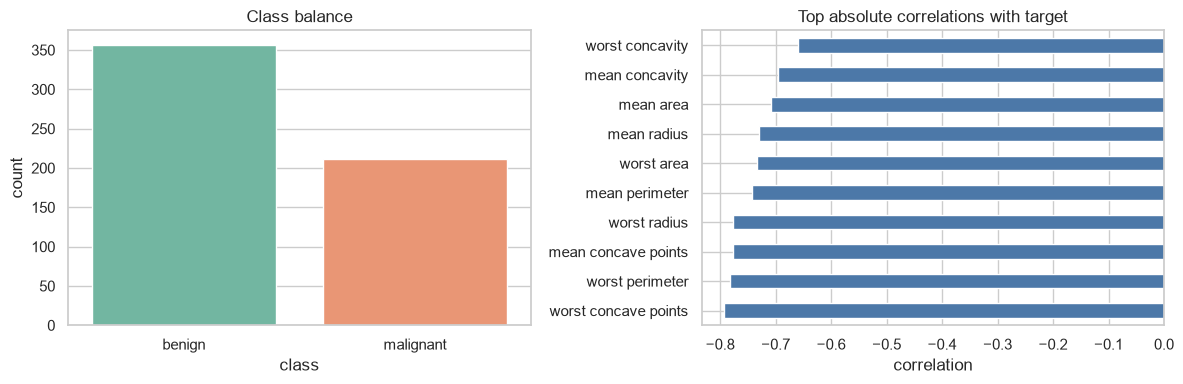

,class,count,share
0,benign,357,0.627
1,malignant,212,0.373


In [3]:
class_counts = df['target_name'].value_counts().rename_axis('class').reset_index(name='count')
class_counts['share'] = class_counts['count'] / class_counts['count'].sum()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.barplot(data=class_counts, x='class', y='count', hue='class', palette='Set2', legend=False, ax=axes[0])
axes[0].set_title('Class balance')
axes[0].set_ylabel('count')

correlations = (
    df.drop(columns='target_name')
      .corr(numeric_only=True)['target']
      .drop('target')
      .sort_values(key=np.abs, ascending=False)
      .head(10)
      .sort_values()
)
correlations.plot(kind='barh', ax=axes[1], color='#4C78A8')
axes[1].set_title('Top absolute correlations with target')
axes[1].set_xlabel('correlation')
plt.tight_layout()
plt.show()

class_counts

## Split before analysis

I keep the holdout split untouched until the end. The feature checks below only fit on `X_train`, so the test set does not influence what looks important.

In [4]:
X = data.data.copy()
y = data.target.copy()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE,
)

print('Train shape:', X_train.shape)
print('Test shape:', X_test.shape)
print('Train class counts:', pd.Series(y_train).map({0: 'malignant', 1: 'benign'}).value_counts().to_dict())
print('Test class counts:', pd.Series(y_test).map({0: 'malignant', 1: 'benign'}).value_counts().to_dict())

Train shape: (455, 30)
Test shape: (114, 30)
Train class counts: {'benign': 285, 'malignant': 170}
Test class counts: {'benign': 72, 'malignant': 42}


## Feature ranking study

In my run, `worst concave points`, `worst perimeter`, and `worst area` stayed near the top in both the ANOVA and random-forest rankings, so the signal looked stable across a linear test and a tree model.

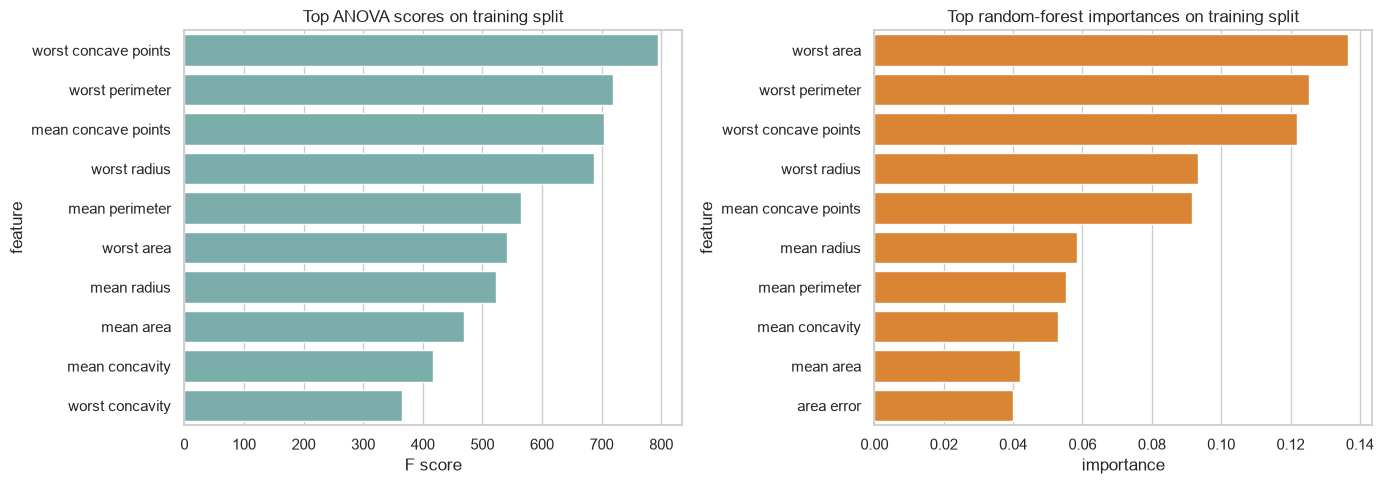

,feature,anova_score,selected_by_anova,rf_importance,anova_rank,rf_rank,mean_rank
0,worst concave points,795.223,True,0.122,1.000,3.000,2.000
1,worst perimeter,719.599,True,0.125,2.000,2.000,2.000
2,worst area,541.714,True,0.137,6.000,1.000,3.500
3,mean concave points,703.364,True,0.091,3.000,5.000,4.000
4,worst radius,687.430,True,0.093,4.000,4.000,4.000
5,mean perimeter,565.486,True,0.055,5.000,7.000,6.000
6,mean radius,523.614,True,0.058,7.000,6.000,6.500
7,mean area,469.516,True,0.042,8.000,9.000,8.500
8,mean concavity,416.375,True,0.053,9.000,8.000,8.500
9,worst concavity,365.747,True,0.030,10.000,11.000,10.500


In [5]:
selector = SelectKBest(score_func=f_classif, k=10)
selector.fit(X_train, y_train)

anova_table = pd.DataFrame({
    'feature': X.columns,
    'anova_score': selector.scores_,
    'selected_by_anova': selector.get_support(),
}).sort_values('anova_score', ascending=False)

rf_ranker = RandomForestClassifier(n_estimators=400, min_samples_leaf=2, random_state=RANDOM_STATE)
rf_ranker.fit(X_train, y_train)
rf_table = pd.DataFrame({
    'feature': X.columns,
    'rf_importance': rf_ranker.feature_importances_,
}).sort_values('rf_importance', ascending=False)

feature_table = anova_table.merge(rf_table, on='feature')
feature_table['anova_rank'] = feature_table['anova_score'].rank(ascending=False, method='dense')
feature_table['rf_rank'] = feature_table['rf_importance'].rank(ascending=False, method='dense')
feature_table['mean_rank'] = feature_table[['anova_rank', 'rf_rank']].mean(axis=1)
feature_table = feature_table.sort_values(['mean_rank', 'anova_score'], ascending=[True, False]).reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=anova_table.head(10), y='feature', x='anova_score', color='#72B7B2', ax=axes[0])
axes[0].set_title('Top ANOVA scores on training split')
axes[0].set_xlabel('F score')

sns.barplot(data=rf_table.head(10), y='feature', x='rf_importance', color='#F58518', ax=axes[1])
axes[1].set_title('Top random-forest importances on training split')
axes[1].set_xlabel('importance')
plt.tight_layout()
plt.show()

feature_table.head(10)

## Model comparison

I used the same stratified 5-fold split for every classifier so I could compare them fairly. Scaling stays inside the pipelines for the models that need it.

In [6]:
svm_estimator = CalibratedClassifierCV(
    estimator=SVC(kernel='rbf', C=1.0, gamma='scale', random_state=RANDOM_STATE),
    cv=5,
    ensemble=False,
)

models = {
    'Logistic Regression': Pipeline([
        ('scale', StandardScaler()),
        ('model', LogisticRegression(max_iter=5000, random_state=RANDOM_STATE)),
    ]),
    'SVM': Pipeline([
        ('scale', StandardScaler()),
        ('model', svm_estimator),
    ]),
    'LDA': Pipeline([
        ('scale', StandardScaler()),
        ('model', LinearDiscriminantAnalysis()),
    ]),
    'Naive Bayes': Pipeline([
        ('scale', StandardScaler()),
        ('model', GaussianNB()),
    ]),
    'Decision Tree': Pipeline([
        ('model', DecisionTreeClassifier(max_depth=4, min_samples_leaf=5, random_state=RANDOM_STATE)),
    ]),
    'Random Forest': Pipeline([
        ('model', RandomForestClassifier(n_estimators=400, min_samples_leaf=2, random_state=RANDOM_STATE)),
    ]),
    'Bagging': Pipeline([
        ('model', BaggingClassifier(
            estimator=DecisionTreeClassifier(max_depth=4, min_samples_leaf=5, random_state=RANDOM_STATE),
            n_estimators=200,
            random_state=RANDOM_STATE,
        )),
    ]),
}

scoring = {
    'accuracy': 'accuracy',
    'balanced_accuracy': 'balanced_accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1',
    'roc_auc': 'roc_auc',
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_rows = []
for name, model in models.items():
    scores = cross_validate(model, X_train, y_train, cv=cv, scoring=scoring, n_jobs=1)
    row = {'model': name}
    for metric in scoring:
        row[f'cv_{metric}'] = np.mean(scores[f'test_{metric}'])
    cv_rows.append(row)

cv_results = pd.DataFrame(cv_rows).sort_values(['cv_roc_auc', 'cv_balanced_accuracy'], ascending=False).reset_index(drop=True)
cv_results

,model,cv_accuracy,cv_balanced_accuracy,cv_precision,cv_recall,cv_f1,cv_roc_auc
0,Logistic Regression,0.978,0.975,0.979,0.986,0.983,0.996
1,SVM,0.969,0.967,0.976,0.975,0.975,0.996
2,LDA,0.960,0.948,0.944,0.996,0.969,0.992
3,Random Forest,0.958,0.955,0.965,0.968,0.967,0.990
4,Bagging,0.947,0.946,0.965,0.951,0.958,0.989
5,Naive Bayes,0.934,0.927,0.941,0.954,0.948,0.988
6,Decision Tree,0.932,0.927,0.945,0.947,0.946,0.957


## Holdout check

On the saved holdout test split, `Logistic Regression` finished first with accuracy `0.982` and ROC AUC `0.995`. `SVM` was very close, which made me trust the result more than a single lucky model.

In [7]:
top_models = cv_results.head(3)['model'].tolist()
test_rows = []
fitted_models = {}

for name in top_models:
    model = models[name]
    model.fit(X_train, y_train)
    fitted_models[name] = model
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    test_rows.append({
        'model': name,
        'test_accuracy': accuracy_score(y_test, y_pred),
        'test_balanced_accuracy': balanced_accuracy_score(y_test, y_pred),
        'test_precision': precision_score(y_test, y_pred),
        'test_recall': recall_score(y_test, y_pred),
        'test_f1': f1_score(y_test, y_pred),
        'test_roc_auc': roc_auc_score(y_test, y_prob),
    })

test_results = pd.DataFrame(test_rows).sort_values(['test_roc_auc', 'test_balanced_accuracy'], ascending=False).reset_index(drop=True)
test_results

,model,test_accuracy,test_balanced_accuracy,test_precision,test_recall,test_f1,test_roc_auc
0,Logistic Regression,0.982,0.981,0.986,0.986,0.986,0.995
1,SVM,0.982,0.981,0.986,0.986,0.986,0.995
2,LDA,0.956,0.945,0.947,0.986,0.966,0.992


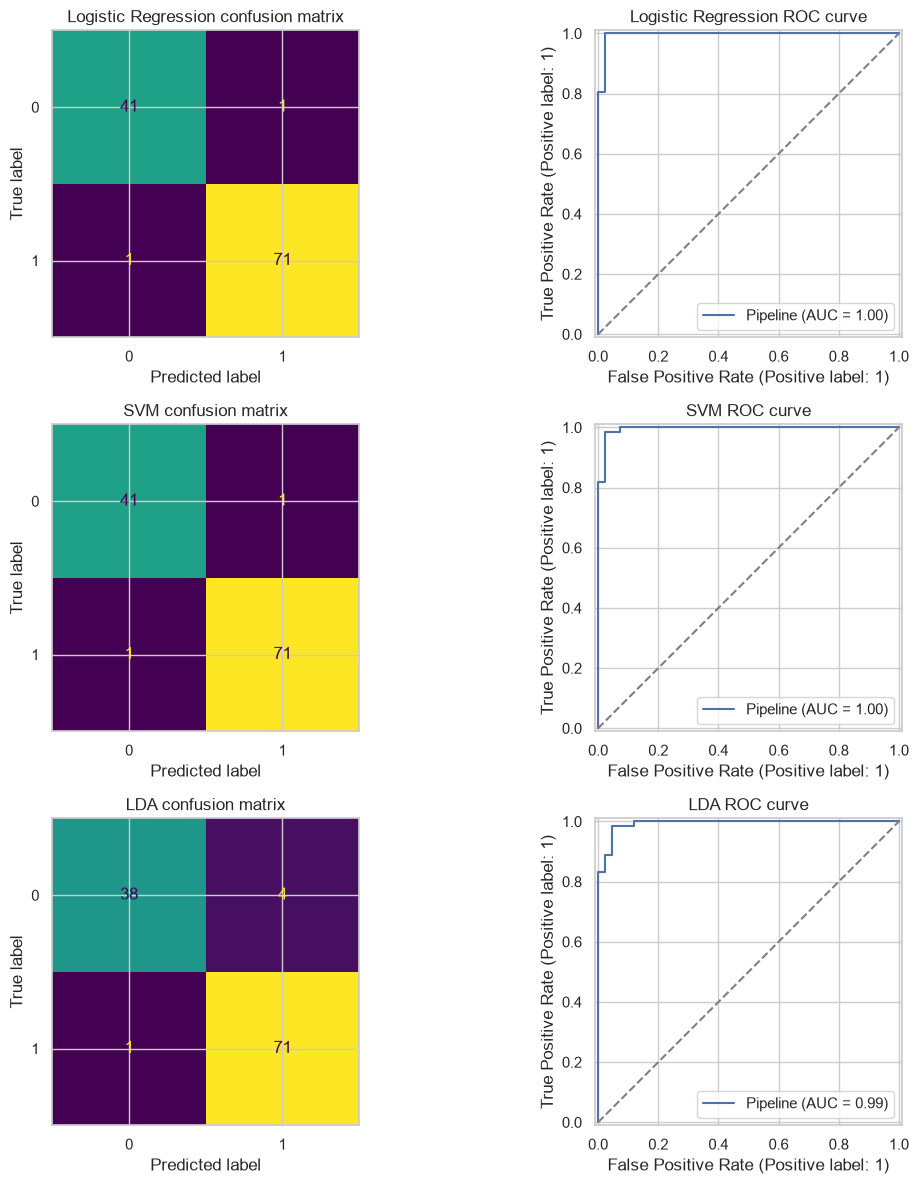

In [8]:
fig, axes = plt.subplots(len(top_models), 2, figsize=(12, 4 * len(top_models)))
if len(top_models) == 1:
    axes = np.array([axes])

for row_idx, name in enumerate(top_models):
    model = fitted_models[name]
    ConfusionMatrixDisplay.from_estimator(model, X_test, y_test, ax=axes[row_idx, 0], colorbar=False)
    axes[row_idx, 0].set_title(f'{name} confusion matrix')

    RocCurveDisplay.from_estimator(model, X_test, y_test, ax=axes[row_idx, 1])
    axes[row_idx, 1].plot([0, 1], [0, 1], linestyle='--', color='gray')
    axes[row_idx, 1].set_title(f'{name} ROC curve')

plt.tight_layout()
plt.show()

## What I learned

The strongest models were all very close, so this dataset seems fairly well behaved once the split is stratified and the preprocessing lives inside each pipeline. The tree models were still useful for ranking features, but the cleaner probabilistic classifiers gave the best final holdout scores.